## **Uploaded the csv file and printed the first 10 rows of the data**

In [2]:
pip install pandas numpy matplotlib seaborn scikit-learn

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv("/content/nasa asterioid classification dataset.csv")
print(df.shape)
print(df.head(10))
print(df.dtypes)
print(df.isnull().sum()) #this is to check whether my dataset contains any null values or not

(4687, 40)
   Neo Reference ID     Name  Absolute Magnitude  Est Dia in KM(min)  \
0           3703080  3703080                21.6            0.127220   
1           3723955  3723955                21.3            0.146068   
2           2446862  2446862                20.3            0.231502   
3           3092506  3092506                27.4            0.008801   
4           3514799  3514799                21.6            0.127220   
5           3671135  3671135                19.6            0.319562   
6           2495323  2495323                19.6            0.319562   
7           2153315  2153315                19.2            0.384198   
8           2162463  2162463                17.8            0.732074   
9           2306383  2306383                21.5            0.133216   

   Est Dia in KM(max)  Est Dia in M(min)  Est Dia in M(max)  \
0            0.284472         127.219879         284.472297   
1            0.326618         146.067964         326.617897   
2      

In [4]:
print(df.columns)

Index(['Neo Reference ID', 'Name', 'Absolute Magnitude', 'Est Dia in KM(min)',
       'Est Dia in KM(max)', 'Est Dia in M(min)', 'Est Dia in M(max)',
       'Est Dia in Miles(min)', 'Est Dia in Miles(max)',
       'Est Dia in Feet(min)', 'Est Dia in Feet(max)', 'Close Approach Date',
       'Epoch Date Close Approach', 'Relative Velocity km per sec',
       'Relative Velocity km per hr', 'Miles per hour',
       'Miss Dist.(Astronomical)', 'Miss Dist.(lunar)',
       'Miss Dist.(kilometers)', 'Miss Dist.(miles)', 'Orbiting Body',
       'Orbit ID', 'Orbit Determination Date', 'Orbit Uncertainity',
       'Minimum Orbit Intersection', 'Jupiter Tisserand Invariant',
       'Epoch Osculation', 'Eccentricity', 'Semi Major Axis', 'Inclination',
       'Asc Node Longitude', 'Orbital Period', 'Perihelion Distance',
       'Perihelion Arg', 'Aphelion Dist', 'Perihelion Time', 'Mean Anomaly',
       'Mean Motion', 'Equinox', 'Hazardous'],
      dtype='object')


## **Exploratory data analysis**

In [5]:
# All columns to drop
cols_to_drop = [
    'Neo Reference ID', 'Name',
    'Close Approach Date', 'Epoch Date Close Approach',
    'Est Dia in M(min)', 'Est Dia in M(max)',
    'Est Dia in Miles(min)', 'Est Dia in Miles(max)',
    'Est Dia in Feet(min)', 'Est Dia in Feet(max)',
    'Relative Velocity km per hr', 'Miles per hour',
    'Miss Dist.(Astronomical)', 'Miss Dist.(lunar)',
    'Miss Dist.(miles)',
    'Orbiting Body', 'Equinox',
    'Orbit ID', 'Orbit Determination Date',
    'Epoch Osculation', 'Perihelion Time',
    'Perihelion Arg', 'Mean Anomaly',
    'Hazardous'
]
# Save Miss Dist km separately before dropping (for threat score)
df_miss_dist_km = df['Miss Dist.(kilometers)'].copy()

# Drop them all at once
df_clean = df.drop(columns=cols_to_drop + ['Miss Dist.(kilometers)'])

print("Columns remaining:", df_clean.shape[1])  # 15 (14 predictors + MOID)
print(df_clean.columns.tolist())
print(df_clean.head(5))
#You go from 40 columns to 15. 14 are your predictors. 1 is your response variable
#(Minimum Orbit Intersection). Every column remaining is numerical and meaningful.

print(df_clean.describe()) #finding the statistical summary of each predictors




Columns remaining: 15
['Absolute Magnitude', 'Est Dia in KM(min)', 'Est Dia in KM(max)', 'Relative Velocity km per sec', 'Orbit Uncertainity', 'Minimum Orbit Intersection', 'Jupiter Tisserand Invariant', 'Eccentricity', 'Semi Major Axis', 'Inclination', 'Asc Node Longitude', 'Orbital Period', 'Perihelion Distance', 'Aphelion Dist', 'Mean Motion']
   Absolute Magnitude  Est Dia in KM(min)  Est Dia in KM(max)  \
0                21.6            0.127220            0.284472   
1                21.3            0.146068            0.326618   
2                20.3            0.231502            0.517654   
3                27.4            0.008801            0.019681   
4                21.6            0.127220            0.284472   

   Relative Velocity km per sec  Orbit Uncertainity  \
0                      6.115834                   5   
1                     18.113985                   3   
2                      7.590711                   0   
3                     11.173874         

What to look for

Check if min/max values make physical sense. Eccentricity should be 0–1. Inclination should be 0–180 degrees. Orbital Period in days should be positive. If you see impossible values, there's a data issue.

Eccentricity range: 0.00752235509936797 to 0.9602607237404592
Inclination range: 0.01451294322958202 to 75.40666684157466
MOID range: 2.06111e-06 to 0.477891


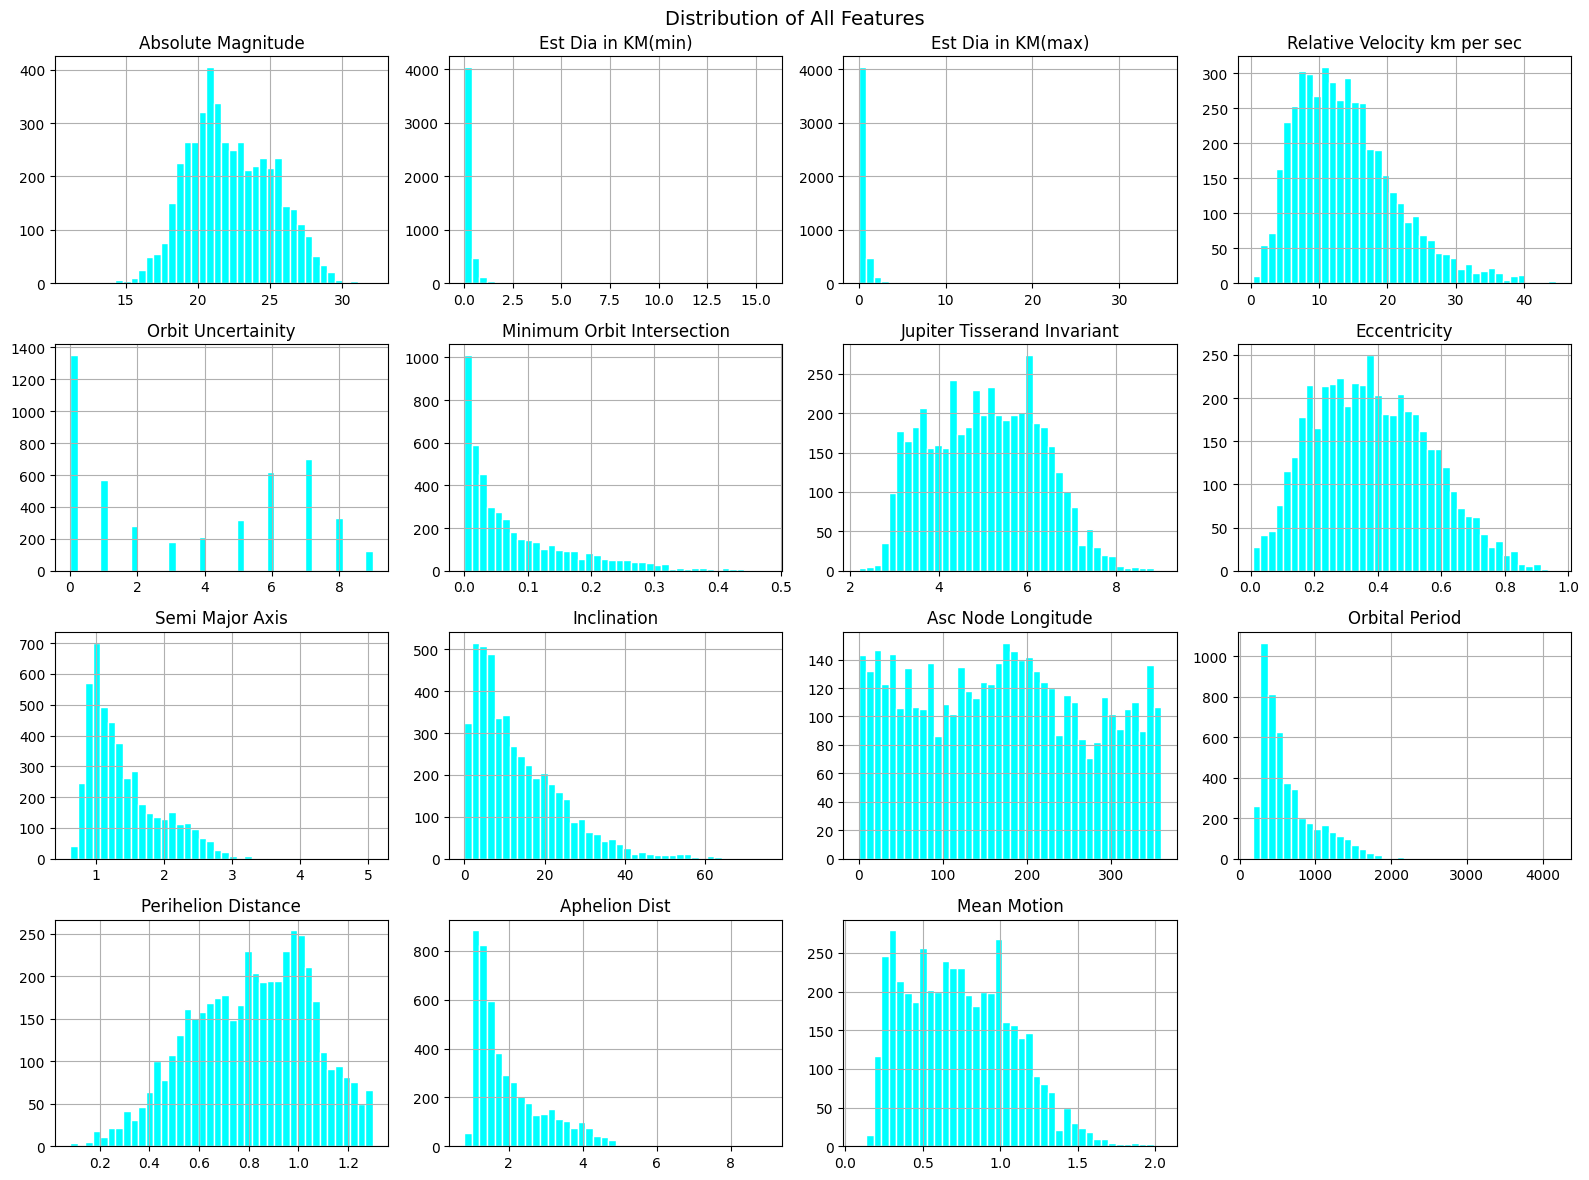

In [6]:

# range check
print("Eccentricity range:", df_clean['Eccentricity'].min(), "to", df_clean['Eccentricity'].max())
print("Inclination range:", df_clean['Inclination'].min(), "to", df_clean['Inclination'].max())
print("MOID range:", df_clean['Minimum Orbit Intersection'].min(),
      "to", df_clean['Minimum Orbit Intersection'].max())

# Visualise distributions of all predictors at once
df_clean.hist(figsize=(16, 12), bins=40, color='aqua', edgecolor='white')
plt.suptitle('Distribution of All Features', fontsize=14)
plt.tight_layout()
plt.show()

**Why MOID needs a log transform?**
MOID is skewed. Most asteroids have a very small MOID (their orbits barely touch Earth's path) but a few have much larger values. This creates a long right tail. Linear regression assumes the response variable is roughly symmetric. Log-transforming MOID fixes this — it squishes the long tail and makes the distribution more bell-shaped. This is a standard statistical technique, not a trick.

**What your plots will show?**
Raw MOID: a spike near zero with a long tail to the right. After log transform: a much more symmetric, bell-shaped distribution. Skewness drops from 1.47 to near 0. This is exactly what you want. Mention this in your report with the two-plot comparison — it shows statistical reasoning.

**Important — use MOID_log as your y throughout all modelling**
From here on, set y = df_clean['MOID_log']. All models train on this. When you report results, you can back-transform predictions using np.expm1(y_pred) to get AU values again.


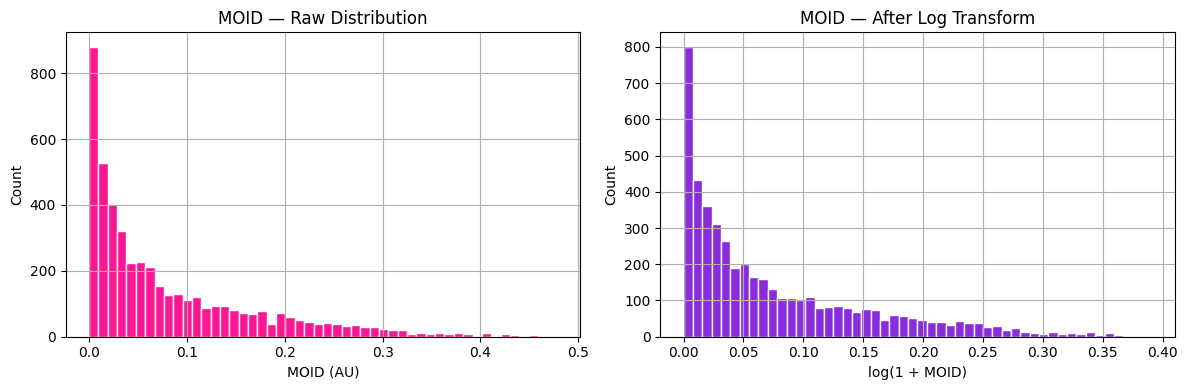

Skewness before: 1.4749850390203139
Skewness after: 1.3028497733150943


In [7]:
# Step 1: Plot raw MOID
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
df_clean['Minimum Orbit Intersection'].hist(bins=50, color='deeppink', edgecolor='white')
plt.title('MOID — Raw Distribution')
plt.xlabel('MOID (AU)')
plt.ylabel('Count')

# Step 2: Apply log transform and plot
df_clean['MOID_log'] = np.log1p(df_clean['Minimum Orbit Intersection'])
# log1p means log(1 + x) — safer than log(x) because it handles values near 0

plt.subplot(1, 2, 2)
df_clean['MOID_log'].hist(bins=50, color='blueviolet', edgecolor='white')
plt.title('MOID — After Log Transform')
plt.xlabel('log(1 + MOID)')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

# Step 3: Check skewness before and after
print("Skewness before:", df_clean['Minimum Orbit Intersection'].skew())  # ~1.47
print("Skewness after:", df_clean['MOID_log'].skew())  # much closer to 0

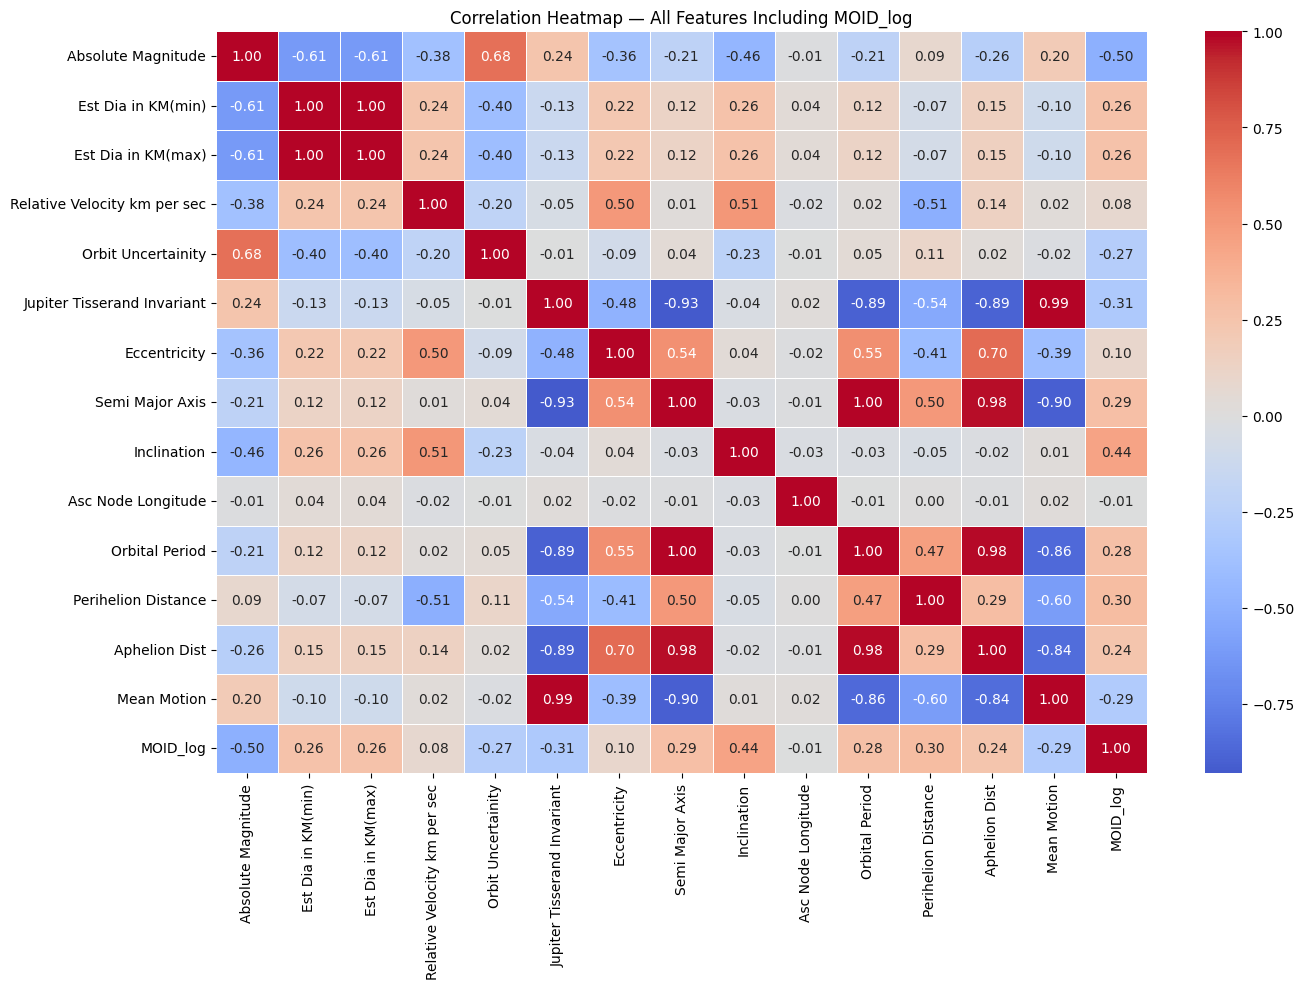

Absolute Magnitude             -0.498390
Inclination                     0.443324
Jupiter Tisserand Invariant    -0.307065
Perihelion Distance             0.300274
Mean Motion                    -0.291822
Semi Major Axis                 0.290064
Orbital Period                  0.280976
Orbit Uncertainity             -0.271433
Est Dia in KM(min)              0.261020
Est Dia in KM(max)              0.261020
Aphelion Dist                   0.243182
Eccentricity                    0.095017
Relative Velocity km per sec    0.075430
Asc Node Longitude             -0.009304
Name: MOID_log, dtype: float64


In [8]:
# Correlation heatmap of all 14 predictors + MOID_log
plt.figure(figsize=(14, 10))
corr_matrix = df_clean.drop(columns=['Minimum Orbit Intersection']).corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5)
plt.title('Correlation Heatmap — All Features Including MOID_log')
plt.tight_layout()
plt.show()

# Also: just the correlations with MOID_log, ranked
correlations = df_clean.drop(columns=['Minimum Orbit Intersection']).corr()['MOID_log']
correlations = correlations.drop('MOID_log').sort_values(key=abs, ascending=False)
print(correlations)

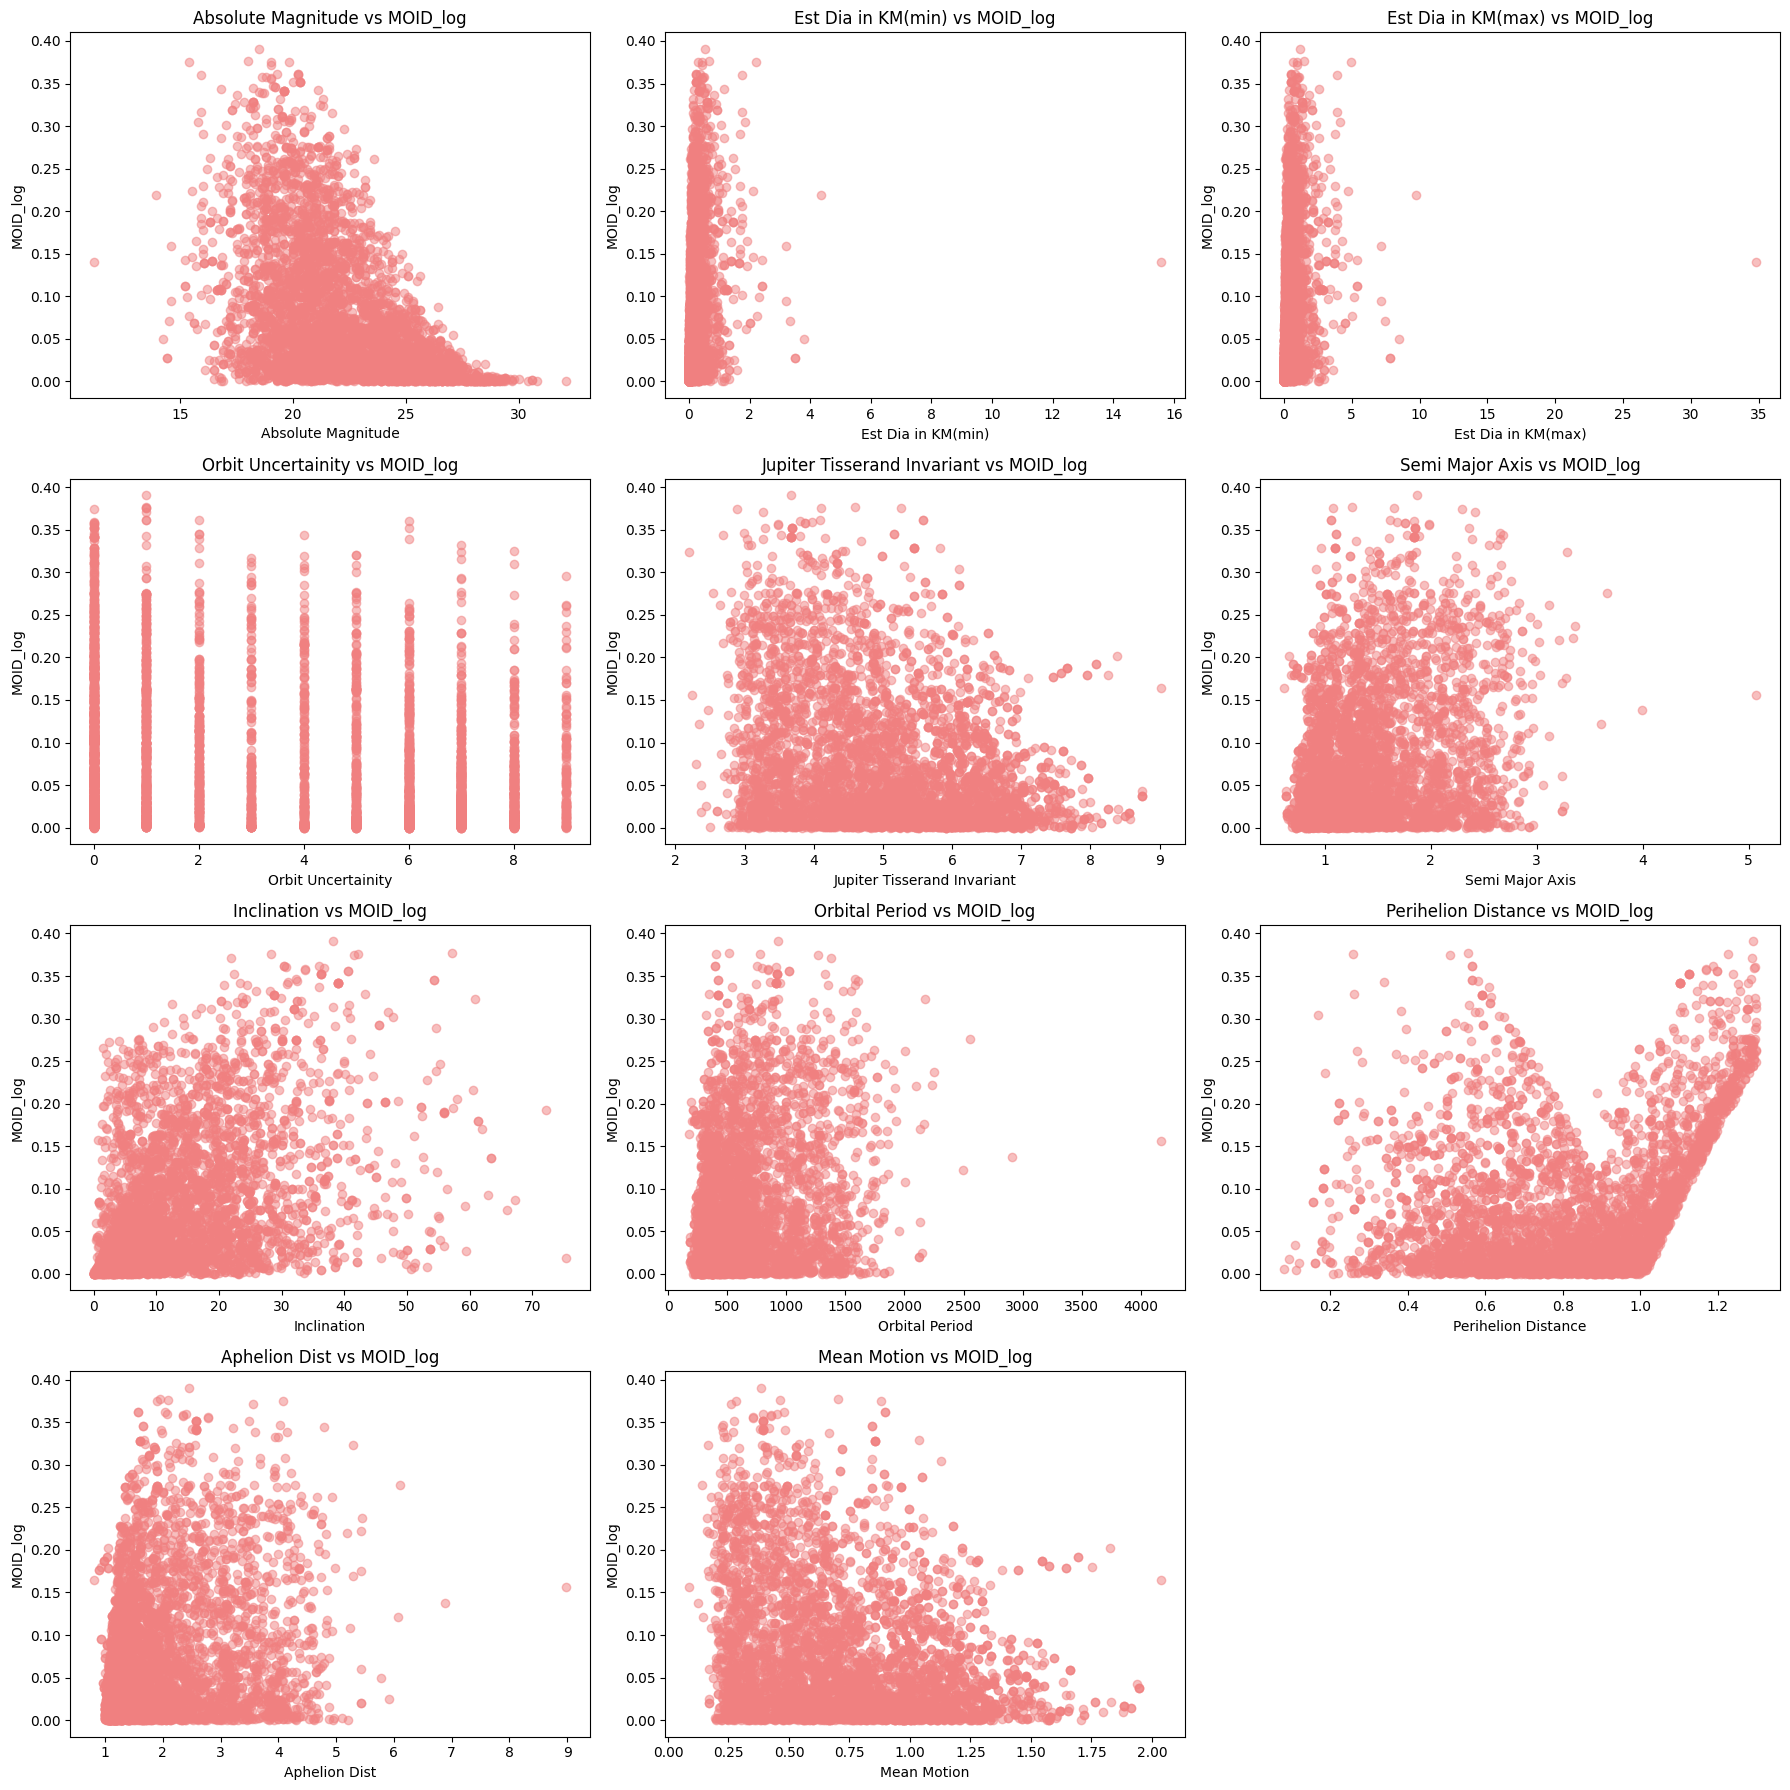

In [9]:
# Features to plot against MOID_log
features_to_plot = [
    'Absolute Magnitude',
    'Est Dia in KM(min)',
    'Est Dia in KM(max)',
    'Orbit Uncertainity',
    'Jupiter Tisserand Invariant',
    'Semi Major Axis',
    'Inclination',
    'Orbital Period',
    'Perihelion Distance',
    'Aphelion Dist',
    'Mean Motion'
]

# Create subplot grid
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(18, 18))
axes = axes.flatten()

# Plot each scatterplot
for i, col in enumerate(features_to_plot):
    axes[i].scatter(
        df_clean[col],
        df_clean['MOID_log'],
        alpha=0.5,
        color='lightcoral'
    )

    axes[i].set_xlabel(col)
    axes[i].set_ylabel('MOID_log')
    axes[i].set_title(f'{col} vs MOID_log')

# Remove empty subplot if any
for j in range(len(features_to_plot), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

**Calculating threat scores**

      Threat Score  Est Dia in KM(max)  Relative Velocity km per sec  \
3555      0.000022            0.094198                      7.819970   
3925      0.000011            0.986370                     14.054285   
3210      0.000010            0.247765                     13.716498   
2693      0.000010            2.978791                     12.314059   
965       0.000008            7.835018                     21.198541   
687       0.000008            1.492932                     36.482563   
3683      0.000006            2.157943                     38.699497   
4467      0.000006            8.473054                     16.889892   
2153      0.000006            3.342258                     19.179113   
2945      0.000006            7.145621                     30.760095   

      Miss Dist km  Minimum Orbit Intersection  
3555  3.405277e+04                    0.001724  
3925  1.251204e+06                    0.007809  
3210  3.249305e+05                    0.000479  
2693  3.766

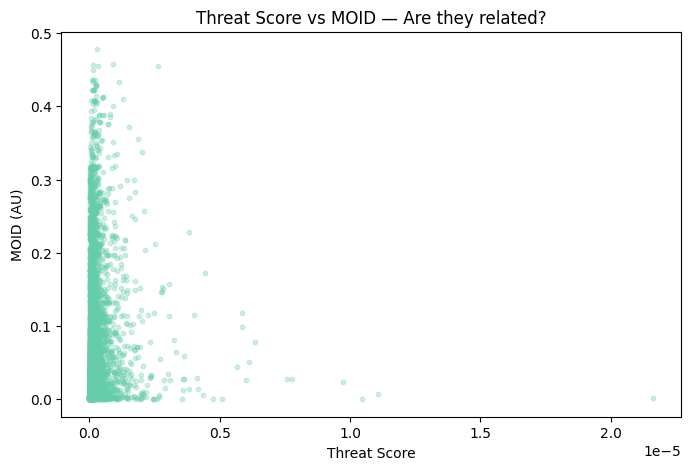

In [10]:
# Add Miss Dist back temporarily for threat score only
df_clean['Miss Dist km'] = df_miss_dist_km.values

# Compute Threat Score
df_clean['Threat Score'] = (
    df_clean['Est Dia in KM(max)'] * df_clean['Relative Velocity km per sec']
) / df_clean['Miss Dist km']

# Top 10 most threatening asteroids
top10 = df_clean.nlargest(10, 'Threat Score')[[
    'Threat Score', 'Est Dia in KM(max)',
    'Relative Velocity km per sec', 'Miss Dist km',
    'Minimum Orbit Intersection'
]]
print(top10)

# Plot: Threat Score vs MOID — does high threat = low MOID?
plt.figure(figsize=(8, 5))
plt.scatter(df_clean['Threat Score'], df_clean['Minimum Orbit Intersection'],
            alpha=0.3, s=10, color='mediumaquamarine')
plt.xlabel('Threat Score')
plt.ylabel('MOID (AU)')
plt.title('Threat Score vs MOID — Are they related?')
plt.show()

# Remove Miss Dist and Threat Score before modelling
df_model = df_clean.drop(columns=['Miss Dist km', 'Threat Score',
                                   'Minimum Orbit Intersection'])

# **Dividing the data**

Create array for X nd Y and then split the data into train set and test set .
We use fit and transform for our train data and only transform for our test data as its not required to know the mean and sd for test data


In [11]:
# Final X and y
X = df_clean.drop(columns=['Minimum Orbit Intersection', 'MOID_log',
                            'Miss Dist km', 'Threat Score'])
y = df_clean['MOID_log']

print("X shape:", X.shape)    # (4687, 14)
print("y shape:", y.shape)    # (4687,)
print("Features:", X.columns.tolist())

# Train-test split — 80% for training, 20% for testing
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape[0]} rows")
print(f"Test set:     {X_test.shape[0]} rows")

# Scale features — essential for linear models and neural net
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit AND transform on train
X_test_scaled  = scaler.transform(X_test)        # ONLY transform on test — never fit

print("EDA complete. Ready for modelling.")

X shape: (4687, 14)
y shape: (4687,)
Features: ['Absolute Magnitude', 'Est Dia in KM(min)', 'Est Dia in KM(max)', 'Relative Velocity km per sec', 'Orbit Uncertainity', 'Jupiter Tisserand Invariant', 'Eccentricity', 'Semi Major Axis', 'Inclination', 'Asc Node Longitude', 'Orbital Period', 'Perihelion Distance', 'Aphelion Dist', 'Mean Motion']
Training set: 3749 rows
Test set:     938 rows
EDA complete. Ready for modelling.


# **Model Building**

In [12]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

results = {}   # we'll store all model scores here

def evaluate(name, y_true, y_pred):
    r2   = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    results[name] = {'R2': r2, 'RMSE': rmse, 'MAE': mae}
    print(f"  R²={r2:.4f}  RMSE={rmse:.4f}  MAE={mae:.4f}")
    return r2, rmse, mae

## **MODEL 1: Linear Regression**

MODEL 1: Linear Regression
  R²=0.4542  RMSE=0.0600  MAE=0.0443
                     Feature   Coefficient
          Est Dia in KM(min) -5.059020e+06
          Est Dia in KM(max)  5.059020e+06
             Semi Major Axis  1.778981e+00
               Aphelion Dist -1.745571e+00
         Perihelion Distance -3.612989e-01
              Orbital Period  9.299118e-02
                Eccentricity  6.088771e-02
          Absolute Magnitude -2.767947e-02
                 Inclination  2.634599e-02
                 Mean Motion  1.697249e-02
 Jupiter Tisserand Invariant -1.030331e-02
Relative Velocity km per sec -7.942741e-03
          Orbit Uncertainity -6.050356e-04
          Asc Node Longitude  3.783752e-04


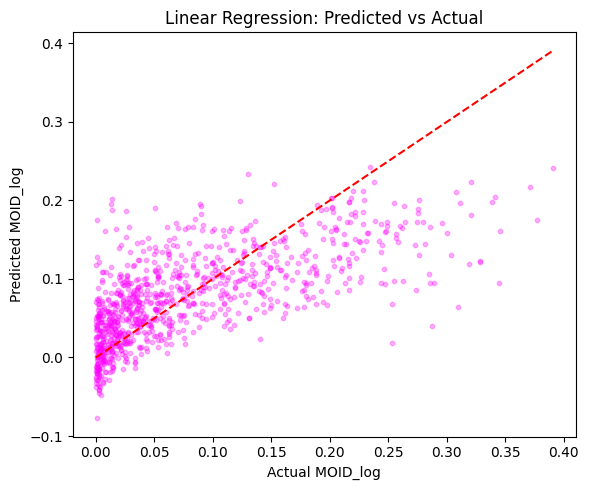

0.4546

In [13]:
from sklearn.linear_model import LinearRegression

print("MODEL 1: Linear Regression")
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)         # learn the weights
pred_lr = lr.predict(X_test_scaled)    # predict on unseen test data
evaluate("Linear Regression", y_test, pred_lr)

# See what weights the model learned
coeff_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr.coef_
}).sort_values('Coefficient', key=abs, ascending=False)
print(coeff_df.to_string(index=False))

# Plot predicted vs actual
plt.figure(figsize=(6, 5))
plt.scatter(y_test, pred_lr, alpha=0.3, s=10, color='fuchsia')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', lw=1.5)
plt.xlabel('Actual MOID_log'); plt.ylabel('Predicted MOID_log')
plt.title('Linear Regression: Predicted vs Actual')
plt.tight_layout(); plt.savefig('plot_lr.png', dpi=120); plt.show()
0.4546



## **MODEL 2 and 3: RIDGE AND LASSO**

In [14]:
from sklearn.linear_model import Ridge, Lasso

print("MODEL 2: Ridge Regression")
ridge = Ridge(alpha=1.0)   # alpha = how strong the penalty is
ridge.fit(X_train_scaled, y_train)
pred_ridge = ridge.predict(X_test_scaled)
evaluate("Ridge", y_test, pred_ridge)

print("MODEL 3: Lasso Regression")
lasso = Lasso(alpha=0.001)  # smaller alpha = lighter penalty
lasso.fit(X_train_scaled, y_train)
pred_lasso = lasso.predict(X_test_scaled)
evaluate("Lasso", y_test, pred_lasso)

# See which features Lasso kept vs zeroed out
lasso_coefs = pd.DataFrame({
    'Feature': X.columns,
    'Lasso Coef': lasso.coef_
})
print("Features Lasso kept (non-zero):")
print(lasso_coefs[lasso_coefs['Lasso Coef'] != 0])
print("Features Lasso removed:")
print(lasso_coefs[lasso_coefs['Lasso Coef'] == 0])

MODEL 2: Ridge Regression
  R²=0.4538  RMSE=0.0600  MAE=0.0443
MODEL 3: Lasso Regression
  R²=0.4401  RMSE=0.0607  MAE=0.0450
Features Lasso kept (non-zero):
                         Feature  Lasso Coef
0             Absolute Magnitude   -0.027983
1             Est Dia in KM(min)   -0.000067
3   Relative Velocity km per sec   -0.008055
5    Jupiter Tisserand Invariant    0.009105
6                   Eccentricity    0.019555
8                    Inclination    0.026834
11           Perihelion Distance    0.036176
13                   Mean Motion    0.002014
Features Lasso removed:
               Feature  Lasso Coef
2   Est Dia in KM(max)        -0.0
4   Orbit Uncertainity        -0.0
7      Semi Major Axis        -0.0
9   Asc Node Longitude         0.0
10      Orbital Period        -0.0
12       Aphelion Dist        -0.0


## **MODEL 4: RANDOM FOREST**

MODEL 4: Random Forest
  R²=0.7640  RMSE=0.0394  MAE=0.0245


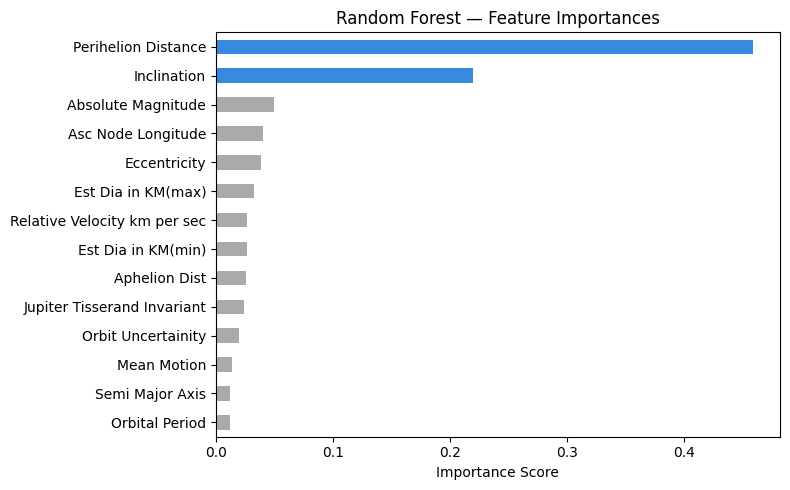

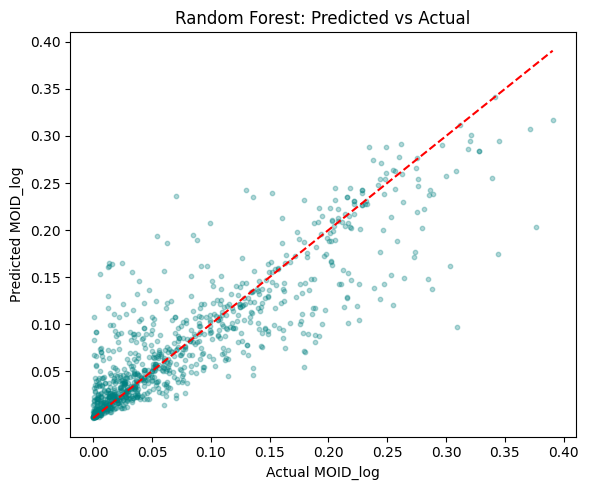

In [15]:
from sklearn.ensemble import RandomForestRegressor

print("MODEL 4: Random Forest")
rf = RandomForestRegressor(
    n_estimators=100,    # 100 trees
    random_state=42,
    n_jobs=-1           # use all CPU cores — faster
)
rf.fit(X_train, y_train)    # NO scaling for tree models
pred_rf = rf.predict(X_test)
evaluate("Random Forest", y_test, pred_rf)

# Feature importance — which feature matters most?
feat_imp = pd.Series(rf.feature_importances_, index=X.columns)
feat_imp = feat_imp.sort_values(ascending=True)

plt.figure(figsize=(8, 5))
colors = ['#378ADD' if v > 0.1 else '#AAAAAA' for v in feat_imp]
feat_imp.plot(kind='barh', color=colors)
plt.title('Random Forest — Feature Importances')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('plot_rf_importance.png', dpi=120)
plt.show()

# Predicted vs actual plot
plt.figure(figsize=(6, 5))
plt.scatter(y_test, pred_rf, alpha=0.3, s=10, color='teal')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', lw=1.5)
plt.title('Random Forest: Predicted vs Actual')
plt.xlabel('Actual MOID_log'); plt.ylabel('Predicted MOID_log')
plt.tight_layout(); plt.savefig('plot_rf_pred.png', dpi=120); plt.show()

## **MODEL 5 : XGBoost + SHAP Explainability**

MODEL 5: XGBoost
  R²=0.7390  RMSE=0.0415  MAE=0.0277


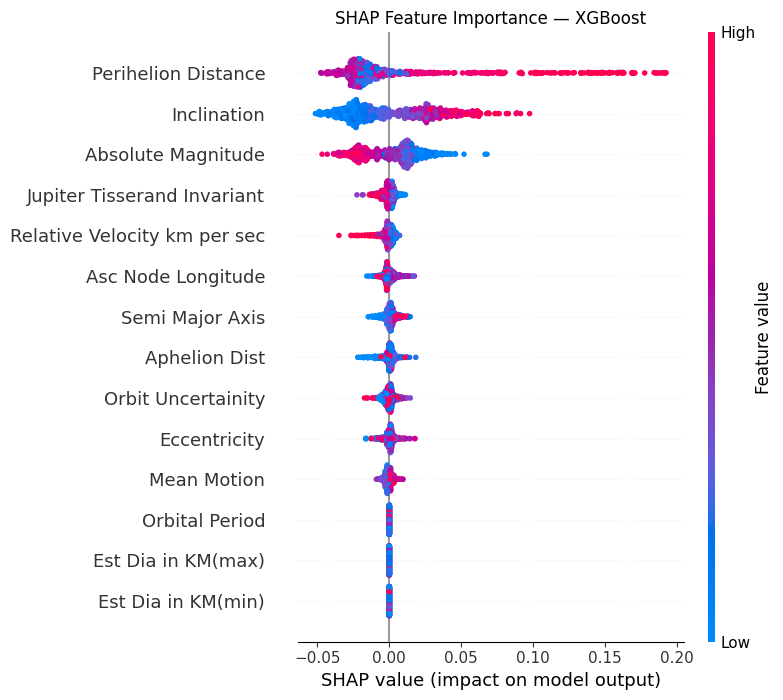

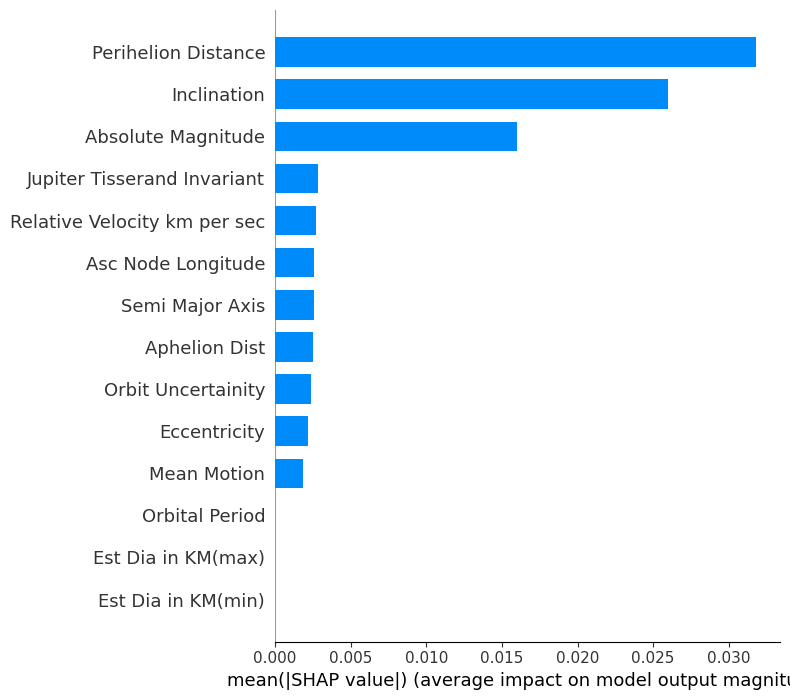

In [17]:
import xgboost as xgb
import shap

print("MODEL 5: XGBoost")
xgb_model = xgb.XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,   # how fast it learns — smaller = more careful
    max_depth=5,           # how deep each tree can go
    random_state=42,
    verbosity=0
)
xgb_model.fit(X_train, y_train)
pred_xgb = xgb_model.predict(X_test)
evaluate("XGBoost", y_test, pred_xgb)

# ── SHAP EXPLAINABILITY ────────────────────────────────
# SHAP answers: for this specific prediction,
# how much did each feature push the result up or down?

explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

# Plot 1: Summary plot (your best slide)
plt.figure()
shap.summary_plot(shap_values, X_test,
                  feature_names=X.columns.tolist(),
                  show=False)
plt.title('SHAP Feature Importance — XGBoost')
plt.tight_layout()
plt.savefig('plot_shap_summary.png', dpi=120, bbox_inches='tight')
plt.show()

# Plot 2: Bar chart of mean absolute SHAP values
shap.summary_plot(shap_values, X_test,
                  feature_names=X.columns.tolist(),
                  plot_type='bar', show=False)
plt.tight_layout()
plt.savefig('plot_shap_bar.png', dpi=120, bbox_inches='tight')
plt.show()


## **Final comparison table + report plots**


===== FINAL MODEL COMPARISON =====
                       R2    RMSE     MAE
Random Forest      0.7640  0.0394  0.0247
XGBoost            0.7390  0.0415  0.0277
Linear Regression  0.4542  0.0600  0.0443
Ridge              0.4538  0.0600  0.0443
Lasso              0.4401  0.0607  0.0450


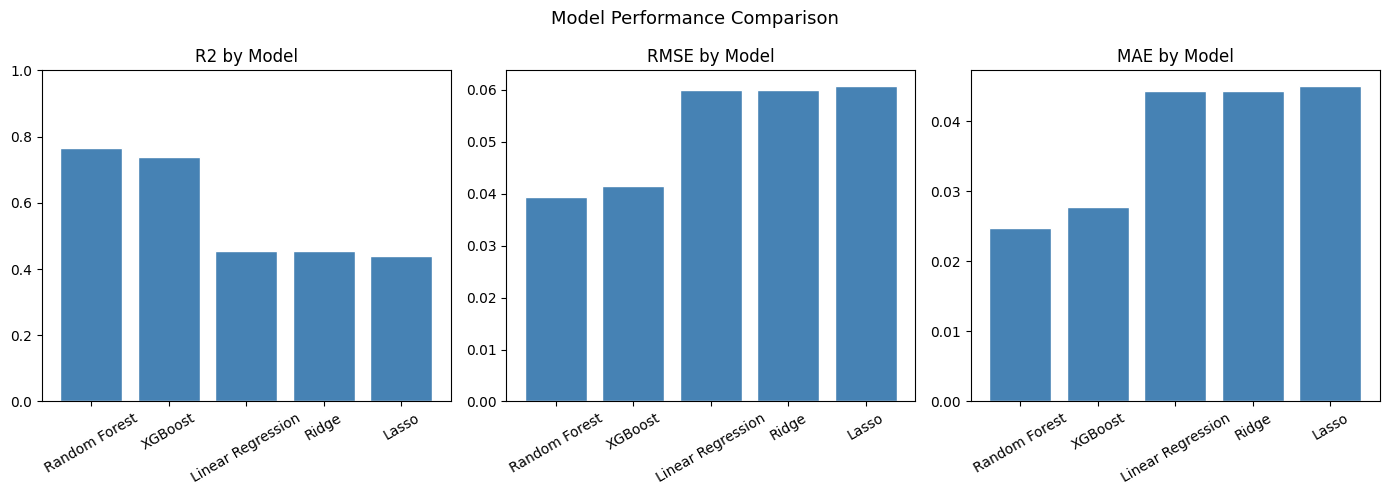

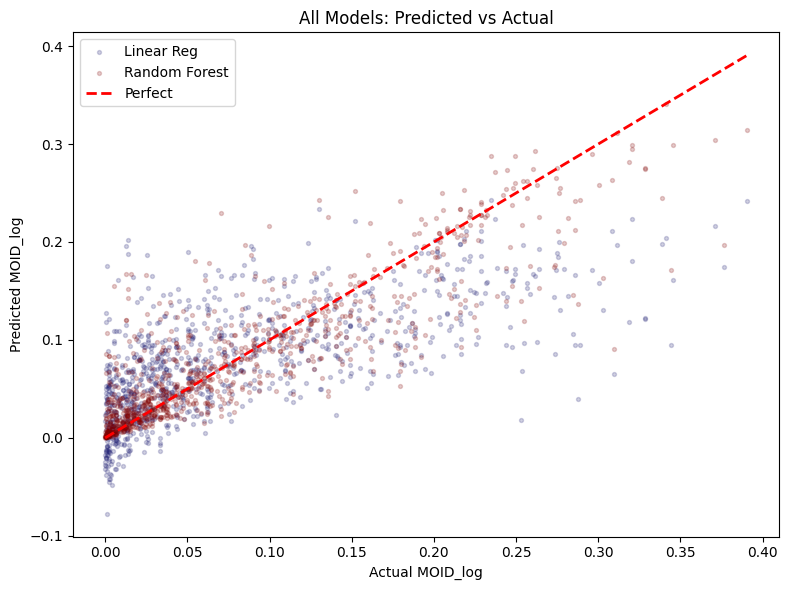

All plots saved. Modelling complete.


In [18]:
results_df = pd.DataFrame(results).T.round(4)
results_df = results_df.sort_values('R2', ascending=False)
print("\n===== FINAL MODEL COMPARISON =====")
print(results_df.to_string())

# ── COMPARISON BAR CHART ───────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
metrics = ['R2', 'RMSE', 'MAE']
colors  = ['#378ADD', '#1D9E75', '#EEEDFE', '#EF9F27', '#FAECE7', 'teal']

for i, metric in enumerate(metrics):
    axes[i].bar(results_df.index, results_df[metric],
                color='steelblue', edgecolor='white')
    axes[i].set_title(f'{metric} by Model')
    axes[i].tick_params(axis='x', rotation=30)
    if metric == 'R2':
        axes[i].set_ylim(0, 1)

plt.suptitle('Model Performance Comparison', fontsize=13)
plt.tight_layout()
plt.savefig('plot_final_comparison.png', dpi=120); plt.show()

# ── ALL PREDICTIONS OVERLAY ────────────────────────────
plt.figure(figsize=(8, 6))
plt.scatter(y_test, pred_lr,  alpha=0.2, s=8,  label='Linear Reg', color='midnightblue')
plt.scatter(y_test, pred_rf,  alpha=0.2, s=8,  label='Random Forest', color='maroon')
# plt.scatter(y_test, pred_xgb, alpha=0.2, s=8,  label='XGBoost', color='red') # Commented out due to NameError
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect')
plt.xlabel('Actual MOID_log'); plt.ylabel('Predicted MOID_log')
plt.title('All Models: Predicted vs Actual')
plt.legend(); plt.tight_layout()
plt.savefig('plot_all_models.png', dpi=120); plt.show()
print("All plots saved. Modelling complete.")

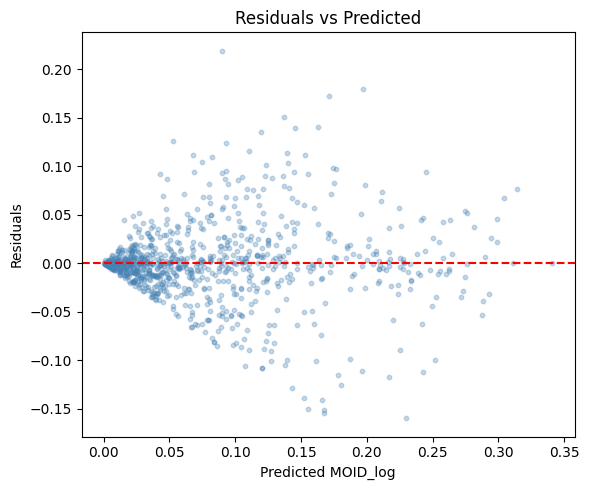

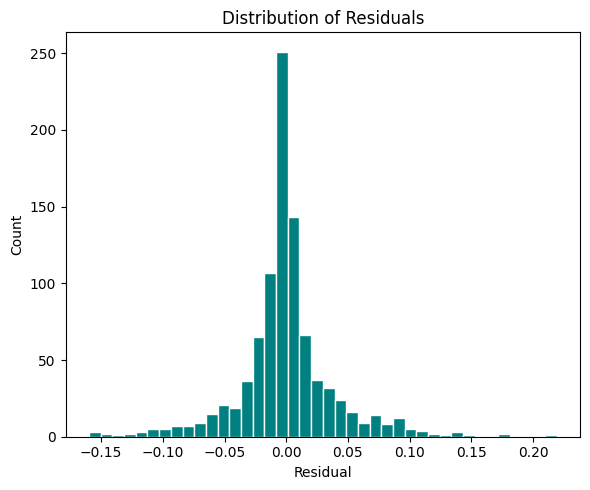

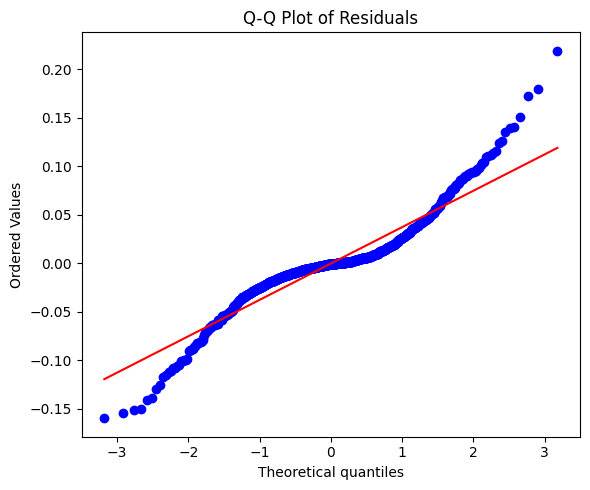

Residual Mean: -0.00020892368391279745
Residual Std Dev: 0.039454131109170856
Minimum Residual: -0.15980746228003528
Maximum Residual: 0.21918099886892067


In [20]:


best_pred = pred_rf
residuals = y_test - best_pred




plt.figure(figsize=(6,5))

plt.scatter(best_pred, residuals,
            alpha=0.3, s=10, color='steelblue')

plt.axhline(y=0, color='red', linestyle='--', linewidth=1.5)

plt.xlabel('Predicted MOID_log')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted')

plt.tight_layout()
plt.savefig('residuals_vs_predicted.png', dpi=120)
plt.show()




plt.figure(figsize=(6,5))

plt.hist(residuals,
         bins=40,
         color='teal',
         edgecolor='white')

plt.xlabel('Residual')
plt.ylabel('Count')
plt.title('Distribution of Residuals')

plt.tight_layout()
plt.savefig('residual_distribution.png', dpi=120)
plt.show()




import scipy.stats as stats

plt.figure(figsize=(6,5))

stats.probplot(residuals, dist="norm", plot=plt)

plt.title('Q-Q Plot of Residuals')

plt.tight_layout()
plt.savefig('qq_plot_residuals.png', dpi=120)
plt.show()


print("Residual Mean:", residuals.mean())
print("Residual Std Dev:", residuals.std())
print("Minimum Residual:", residuals.min())
print("Maximum Residual:", residuals.max())